# Protein-glycan modelling tutorial using a local version of HADDOCK3

# Introduction

This tutorial demonstrates the use of HADDOCK3 for predicting the structure of a protein-glycan complex using information about the protein binding site.

A glycan is a molecule composed of different monosaccharide units, linked to each other by glycosidic bonds. Glycans are involved in a wide range of biological processes, such as cell-cell recognition, cell adhesion, and immune response. Glycan are highly diverse and complex in their structure, as they can involve multiple *branches* and different *linkages*, namely different ways in which a glycosidic bond can connect two monosaccharides. This complexity together with their flexibility makes the prediction of glycan-protein interactions a challenging task.

In this tutorial we will be working with the catalytic domain of the *Humicola Grisea* Cel12A enzyme (PDB code [1OLR](https://www.ebi.ac.uk/pdbe/entry/pdb/1olr) )and a linear homopolymer, *4-beta-glucopyranose*, as glycan (PDB code of the complex [1UU6](https://www.ebi.ac.uk/pdbe/entry/pdb/1uu6)).

The tutorial is based on [A. Ranaudo et al., J. Chem. Inf. Model. 64 (19), 7816-7825, 2024](https://pubs.acs.org/doi/10.1021/acs.jcim.4c01372).

<figure style="text-align: center;">
  <img src="https://www.bonvinlab.org/education/HADDOCK3/HADDOCK3-protein-glycan/1UU6.png">
</figure>
                    
<figure style="text-align: center">
    <i>Picture of the protein-glycan complex in pdb 1UU6</i>

---
# A brief introduction to HADDOCK3

HADDOCK3 is the next generation integrative modelling software in the
long-lasting HADDOCK project. It represents a complete rethinking and rewriting
of the HADDOCK2.X series, implementing a new way to interact with HADDOCK and
offering new features to users who can now define custom workflows.

In the previous HADDOCK2.x versions, users had access to a highly
parameterisable yet rigid simulation pipeline composed of three steps:
`rigid-body docking (it0)`, `semi-flexible refinement (it1)`, and `final refinement (itw)`.

<figure style="text-align: center;">
<img width="75%" src="https://bonvinlab.org/education/HADDOCK3/HADDOCK3-antibody-antigen/HADDOCK2-stages.png">
</figure>

In HADDOCK3, users have the freedom to configure docking workflows into
functional pipelines by combining the different HADDOCK3 modules, thus
adapting the workflows to their projects. HADDOCK3 has therefore developed to
truthfully work like a puzzle of many pieces (simulation modules) that users combine freely. To this end, the old HADDOCK machinery has been modularized,
and several new modules added, including third-party software additions. As a
result, the modularization achieved in HADDOCK3 allows users to duplicate steps
within one workflow (e.g., to repeat twice the `it1` stage of the HADDOCK2.x
rigid workflow).

Note that, for simplification purposes, at this time, not all functionalities of
HADDOCK2.x have been ported to HADDOCK3, which does not (yet) support NMR RDC,
PCS and diffusion anisotropy restraints, cryo-EM restraints and coarse-graining.
Any type of information that can be converted into ambiguous interaction
restraints can, however, be used in HADDOCK3, which also supports the
*ab initio* docking modes of HADDOCK.

<figure style="text-align: center;">
<img width="75%" src="https://bonvinlab.org/education/HADDOCK3/HADDOCK3-antibody-antigen/HADDOCK3-workflow-scheme.png">
</figure>

To keep HADDOCK3 modules organized, we catalogued them into several
categories. However, there are no constraints on piping modules of different
categories.

The main module categories are "topology", "sampling", "refinement",
"scoring", and "analysis". There is no limit to how many modules can belong to a
category. Modules are added as developed, and new categories will be created
if/when needed. You can access the HADDOCK3 documentation page for the list of
all categories and modules. Below is a summary of the available modules:

* **Topology modules**
    * `topoaa`: *generates the all-atom topologies for the CNS engine.*
* **Sampling modules**
    * `rigidbody`: *Rigid body energy minimization with CNS (`it0` in haddock2.x).*
    * `lightdock`: *Third-party glow-worm swam optimization docking software.*
* **Model refinement modules**
    * `flexref`: *Semi-flexible refinement using a simulated annealing protocol through molecular dynamics simulations in torsion angle space (`it1` in haddock2.x).*
    * `emref`: *Refinement by energy minimisation (`itw` EM only in haddock2.4).*
    * `mdref`: *Refinement by a short molecular dynamics simulation in explicit solvent (`itw` in haddock2.X).*
* **Scoring modules**
    * `emscoring`: *scoring of a complex performing a short EM (builds the topology and all missing atoms).*
    * `mdscoring`: *scoring of a complex performing a short MD in explicit solvent + EM (builds the topology and all missing atoms).*
* **Analysis modules**
    * `alascan`: *Performs a systematic (or user-define) alanine scanning mutagenesis of interface residues.*
    * `caprieval`: *Calculates CAPRI metrics (i-RMSD, l-RMSD, Fnat, DockQ) with respect to the top-scoring model or reference structure if provided.*
    * `clustfcc`: *Clusters models based on the fraction of common contacts (FCC)*
    * `clustrmsd`: *Clusters models based on pairwise RMSD matrix calculated with the `rmsdmatrix` module.*
    * `contactmap`: *Generate contact matrices of both intra- and intermolecular contacts and a chordchart of intermolecular contacts.*
    * `rmsdmatrix`: *Calculates the pairwise RMSD matrix between all the models generated in the previous step.*
    * `ilrmsdmatrix`: *Calculates the pairwise interface-ligand-RMSD (il-RMSD) matrix between all the models generated in the previous step.*
    * `seletop`: *Selects the top N models from the previous step.*
    * `seletopclusts`: *Selects the top N clusters from the previous step.*

The HADDOCK3 workflows are defined in simple configuration text files, similar to the TOML format but with extra features.
Contrary to HADDOCK2.X which follows a rigid (yet highly parameterisable)
procedure, in HADDOCK3, you can create your own simulation workflows by
combining a multitude of independent modules that perform specialized tasks.


---
# Software and data setup

In order to follow this tutorial we will start Jupyter session in Colab or other resources, install haddock3 and download the data for the tutorial.

To run this tutorial on Colab we recommand changing the runtime type to use one of the TPU option, which will give you access to more cores. The haddock3 docking run described in this tutorial should complete in about 15 minutes.

For this follow the following steps(comment out the `pip install haddock3` line if you already have a working installation):

In [1]:
#@title 1. Install haddock3, BioPython and py3Dmol
#@markdown Execute this cell to download the required packages.
!pip install haddock3==2026.7.0 --quiet
!pip install py3Dmol --quiet
!pip install BioPython --quiet

In [2]:
#@title 2. Download the tutorial data
#@markdown We are providing pre-processed PDB files for docking and analysis (but the preprocessing of those files will also be explained in this tutorial). The files have been processed to facilitate their use in HADDOCK and to allow comparison with the known reference structure of the complex. Execute this cell to download and decompress the data.
!wget https://surfdrive.surf.nl/public.php/dav/files/fNdwCbjtUtBeuXi -O haddock3-protein-glycan-notebook.zip
!unzip -oq haddock3-protein-glycan-notebook.zip
!rm HADDOCK3-protein-glycan-notebook.zip
import os
from pathlib import Path
BASE_DIR = Path.cwd()
PROJECT_NAME = 'haddock3-protein-glycan'
PROJECT_DIR = BASE_DIR / PROJECT_NAME
os.chdir(PROJECT_DIR)

--2026-07-27 15:39:38--  https://surfdrive.surf.nl/public.php/dav/files/fNdwCbjtUtBeuXi
surfdrive.surf.nl (surfdrive.surf.nl) çözümleniyor... 145.107.8.140, 145.107.56.140
surfdrive.surf.nl (surfdrive.surf.nl)[145.107.8.140]:443 bağlanılıyor... bağlantı kuruldu.
HTTP isteği gönderildi, yanıt bekleniyor... 200 OK
Uzunluk: 76413847 (73M) [application/zip]
Kayıt yeri: `haddock3-protein-glycan-notebook.zip'

haddock3-protein-gl 100%[===================>]  72,87M  36,6MB/s    içinde 2,0s

2026-07-27 15:39:41 (36,6 MB/s) - `haddock3-protein-glycan-notebook.zip' kaydedildi [76413847/76413847]



Unziping the file will create the HADDOCK3-protein-glycan directory which should contain the following directories and files:

* `haddock3`: Contains HADDOCK3 configuration and job files for the various scenarios in this tutorial
* `pdbs`: a directory containing the pre-processed PDB files
* `restraints`: a directory containing the interface information and the corresponding restraint files for HADDOCK3
* `runs`: a directory containing pre-calculated results
* `plots`: Contains pre-generated html plots for the various scenarios in this tutorial

---
# Understanding the Ambiguous Interaction Restraints

The Ambiguous Interaction Restraints (AIRs) are crucial to successful docking, as they guide the modelling process by biasing partners’ conformations and co-orientation towards a certain, hopefully correct conformation of the complex. AIRs consist of the residues located in the interface of a complex.



# Preparing PDB files for docking

In this section we will prepare the PDB files of the protein and glycan for docking. A crystal structure of the protein in the unbound form is available, but you are welcome to use either the bound form or the [Alphafold structure](https://www.alphafold.ebi.ac.uk/entry/Q8NJY3) if you prefer.

Note: Before starting to work on the tutorial, make sure to activate haddock3. For example, if haddock3 was installed using `conda`



In [3]:
!conda activate haddock3


CondaError: Run 'conda init' before 'conda activate'



# Preparing the protein structure

The following command fetches the PDB ID and removes water and heteroatoms (in this case no co-factor is present that should be kept).


In [4]:
! pdb_fetch 1OLR | pdb_tidy -strict | pdb_delhetatm | pdb_keepcoord | pdb_tidy -strict > 1OLR_ready.pdb

__Note__ that the corresponding files can be found in the `pdbs` directory of the archive you downloaded.

# Preparing the glycan structure

We will model the glycan using the [GLYCAM webserver](https://glycam.org/cb/). Our glycan is a linear polymer consisting of 4 beta-D-glucopyranose units. Beta-D-glucopyranose is a common monosaccharide found basically in all the living organisms. In this case the four monosaccharides are linked by beta-1,4-glycosidic bonds, where the *anomeric carbon* (C1) of one monosaccharide is linked to the C4 of the next one.

We can start by accessing the [GLYCAM webserver](https://glycam.org/cb/) where we will model the glycan! 

__*Select the Glc monosaccharide with your mouse.*__

This will add the monosaccharide to the sequence, together with an OH group as *aglycon* (the non-sugar part of a glycan).

Now we need to add a second beta-D-glucopyranose unit to the sequence. We will link it to the first one by a beta-1,4-glycosidic bond.

__*Click one more time on the Glc icon.*__

Now you are asked to specify a linkage.
 __*Select the Beta linkage and the 1-4 option. Do not change the other parameters.*__

This will add the second monosaccharide to the sequence, linked to the first one by a beta-1,4-glycosidic bond.

__*Repeat the process to add the third and fourth monosaccharide units to the sequence.*__

At the end of the process you should observe the following sequence:

__DGlcpb1-4DGlcpb1-4DGlcpb1-4DGlcpa1-OH__

__*Press the Done button and wait for the webserver to process your request. When done, press Download Minimized Structure and download the PDB file.*__

Unfortunately, the glycan structure we just obtained cannot be directly used in HADDOCK as the formant and the residue and atom naming differ from the conventions used in HADDOCK (which follow the naming in the PDB). We will need to edit it to remove the several TER statements GLYCAM placed between the monosaccharides, and to add the [HADDOCK residue name](https://wenmr.science.uu.nl/haddock2.4/library) proper to beta-D-glucopyranose. Importantly, we have to merge the OH aglycon with the first monosaccharide unit, as they are now separated in two different residues.

__*What is the HADDOCK three letter code corresponding to beta-D-glucopyranose?*__

Let us start with the aglycon:

In [5]:
!pdb_selresname -ROH DGlcpb1-4DGlcpb1-4DGlcpb1-4DGlcpb1-OH_structure_min-gas.pdb | pdb_tidy -strict | pdb_chain -B | pdb_rplresname -ROH:BGC > aglycon.pdb

This command selects the GLYCAM residue name proper to the aglycon, changes the chain ID to B, and changes the residue name to the HADDOCK one. The final structure is saved in the aglycon.pdb file. Now we will process the rest of the glycan structure:

In [6]:
!pdb_tidy -strict DGlcpb1-4DGlcpb1-4DGlcpb1-4DGlcpb1-OH_structure_min-gas.pdb | pdb_selres -2:5 | pdb_chain -B | pdb_rplresname -0GB:BGC | pdb_rplresname -4GB:BGC | pdb_reres -1 > sugar.pdb

The pdb_tidy command removes the TER statements between each unit, while pdb_selres selects all the residues except the OH aglycon. The pdb_chain command changes the chain ID to B, and the pdb_rplresname command changes the residue name to BGC. The last command, pdb_reres, renumbers the residues of the glycan starting from 1.

We will now merge the two structures in the 1UU6_l_u.pdb file:

In [7]:
!pdb_merge aglycon.pdb sugar.pdb | pdb_tidy > 1UU6_l_u.pdb

*Note* that the pre-processed glycan structure can be found in the `pdbs` directory of the archive you downloaded.

Now we would like to know how close the modelled glycan is to the reference structure. For this we will use Pymol to superimpose the two structures and calculate the RMSD. Execute the following cell:

In [8]:
from haddock.libs.libnotebooks import align_full

path1 = PROJECT_DIR / "1UU6_l_u.pdb"
path2 = PROJECT_DIR / "1uu6_chain_B.pdb"

# Align the matching chain B from both structures
view = align_full(
    str(path1),
    str(path2),
    chains=["B"]
)

# Remove the default cartoon representation
view.setStyle({})

# First structure: orange sticks
view.addStyle(
    {"model": 0, "chain": "B"},
    {
        "stick": {
            "color": "orange",
            "radius": 0.20
        },
    
    }
)

# Second structure: green sticks
view.addStyle(
    {"model": 1, "chain": "B"},
    {
        "stick": {
            "color": "green"
        },
     
    }
)

# Zoom specifically onto chain B
view.zoomTo({"chain": "B"})

view.show()

Atoms for alignment - Model 1: {'B': 4}, Total: 4
Atoms for alignment - Model 2: {'B': 4}, Total: 4
Model 1: chain B in orange
Model 2: chain B in green
Using 4 atom pairs for alignment
Whole molecule alignment RMSD: 1.306 Å
Chain B RMSD: 1.306 Å


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

__*What is the RMSD between the two glycan structures? In which of the four monosaccharide units is the model accurate? In which ones is it not?*__

---
# Defining restraints for docking
##  Visualising the information about the binding site

Here we mimic a scenario where we have information about the glycan binding site on the protein, but no knowledge about which monosaccharide units are relevant for the binding. In this case (see Fig. 1), all the four beta-D-glucopyranose units are at the interface, although this might not be true in general, especially when longer glycans are considered.

The following residues correspond to the protein binding site, as calculated from the crystal structure of the complex are:

`22,24,59,64,97,103,105,115,120,122,124,131,132,133,134,155,158,205,207`
Let us visualize the interface on our unbound protein structure. For this start PyMol and load the PDB file of the unbound protein:



In [9]:
import py3Dmol
import gzip
import os

view = py3Dmol.view(width=800, height=600)

pdb_file_path = "./pdbs/1OLR_clean.pdb"

if not os.path.exists(pdb_file_path):
    print(f"Error: File not found at {pdb_file_path}")

else:
    if pdb_file_path.endswith(".gz"):
        with gzip.open(pdb_file_path, "rt") as file:
            pdb_data = file.read()
    else:
        with open(pdb_file_path, "r") as file:
            pdb_data = file.read()

    view.addModel(pdb_data, "pdb")

    view.setStyle({'cartoon': {'color': 'white'}})
    view.addStyle({'stick': {'color': 'white'}})
    view.addStyle({'resi': [22, 24, 59, 64, 97, 103, 105, 115, 120, 122, 124, 131, 132, 133, 134, 155, 158, 205, 2076]},{'cartoon':{'color':'red'}})
    view.addStyle({'resi': [22, 24, 59, 64, 97, 103, 105, 115, 120, 122, 124, 131, 132, 133, 134, 155, 158, 205, 207]},{'stick':{'color':'red'}})
    view.addSurface(py3Dmol.SAS, {'opacity':0.4, 'color':'white'})
    view.zoomTo()
    view.show()    


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

__*Are all the highlighted side chains exposed on the surface of the protein?*__

---
# Generating the restraints 

In this section we will define the restraints that will guide the docking of the protein and glycan structures.

A description of the format for the various restraint types supported by HADDOCK can be found in our [Nature Protocol](https://www.nature.com/articles/s41596-024-01011-0.epdf?sharing_token=UHDrW9bNh3BqijxD2u9Xd9RgN0jAjWel9jnR3ZoTv0O8Cyf_B_3QikVaNIBRHxp9xyFsQ7dSV3t-kBtpCaFZWPfnuUnAtvRG_vkef9o4oWuhrOLGbBXJVlaaA9ALOULn6NjxbiqC2VkmpD2ZR_r-o0sgRZoHVz10JqIYOeus_nM%3D) paper, Box 1. Information about various types of distance restraints in HADDOCK can also be found in our [online manual](https://www.bonvinlab.org/software/haddock2.4/airs/) pages.

We will use `haddock3-restraints` to generate the restraints for the protein-glycan docking. For this we need to define two files, one for each molecule, containing on the first line the list of `active residues` (those that should be at the interface) and on the second line the list of `passive residues` (those that can be at the interface

For the protein, we will only define active residues (based on the identified binding site above) and leave the second line (passive) empty, while for the glycan we only define passive residues in the second line, leaving the first line empty. The corresponding files are provided as:

* *restraints/1olr-binding-site.act* for the protein
* *restraints/glycan.pass* for the glycan

The command to generate a HADDOCK ambiguous distance restraint file (.tbl) from those file is:


In [10]:
!haddock3-restraints active_passive_to_ambig restraints/1olr-binding-site.act restraints/glycan.pass > ambig.tbl

We can check the validity of the generated tbl file (useful when manually editing restraint files) with:

In [11]:
!haddock3-restraints validate_tbl ambig.tbl

!
assign 	(segiresi 22 and segid A)
	(
	(resi 1 and segid B)
	or
	(resi 2 and segid B)
	or
	(resi 3 and segid B)
	or
	(resi 4 and segid B)
	) 2.000 2.000 0.000
!
assign 	(segiresi 24 and segid A)
	(
	(resi 1 and segid B)
	or
	(resi 2 and segid B)
	or
	(resi 3 and segid B)
	or
	(resi 4 and segid B)
	) 2.000 2.000 0.000
!
assign 	(segiresi 59 and segid A)
	(
	(resi 1 and segid B)
	or
	(resi 2 and segid B)
	or
	(resi 3 and segid B)
	or
	(resi 4 and segid B)
	) 2.000 2.000 0.000
!
assign 	(segiresi 64 and segid A)
	(
	(resi 1 and segid B)
	or
	(resi 2 and segid B)
	or
	(resi 3 and segid B)
	or
	(resi 4 and segid B)
	) 2.000 2.000 0.000
!
assign 	(segiresi 97 and segid A)
	(
	(resi 1 and segid B)
	or
	(resi 2 and segid B)
	or
	(resi 3 and segid B)
	or
	(resi 4 and segid B)
	) 2.000 2.000 0.000
!
assign 	(segiresi 103 and segid A)
	(
	(resi 1 and segid B)
	or
	(resi 2 and segid B)
	or
	(resi 3 and segid B)
	or
	(resi 4 and segid B)
	) 2.000 2.000 0.000
!
assign 	(segiresi 105 and segid A)
	(

__*Inspect the generated file. Can you understand the syntax?*__

__*What is the distance range (lower and upper limits) defined for the restraints?*__

Distance restraints in the HADDOCK/CNS syntax are defined as:

`assign (selection1) (selection2) distance, lower-bound correction, upper-bound correction`
where the lower limit for the distance is calculated as: `distance minus lower-bound correction` and the upper limit as: `distance plus upper-bound correction`.

---
# Setting up the docking with HADDOCK3

Now that we have all required files at hand (PDB and restraints files) it is time to setup our docking protocol. For this we need to create a HADDOCK3 configuration file that will define the docking workflow. We will illustrate this flexibility by introducing a clustering step after the initial rigid-body docking stage, select up to 20 models per cluster and refine all of those.

HADDOCK3 also provides an analysis module (`caprieval`) that allows to compare models to either the best scoring model (if no reference is given) or to a reference structure, which in our case we have at hand.

The basic workflow for all three scenarios will consists of the following modules, with some differences in the restraints used and some parameter settings (see below):

1. `topoaa`: *Generates the topologies for the CNS engine and build missing atoms*
2. `rigidbody`: *Rigid body energy minimisation (it0 in haddock2.x)*
3. `caprieval`: *Calculates CAPRI metrics (i-RMSD, l-RMSD, Fnat, DockQ) with respect to the top scoring model or reference structure if provided*
4. `ilrmsdmatrix`: *Calculate the ilRMSD matrix between the generated models*
5. `clustrmsd`: *Cluster the ilRMSD matrix in 50 clusters*
6. `seletopclusts`: *Selection of the top20 models of each clusters*
7. `caprieval`: *Calculates CAPRI metrics (i-RMSD, l-RMSD, Fnat, DockQ) with respect to the top scoring model or reference structure if provided*
8. `flexref`: *Semi-flexible refinement of the interface (it1 in haddock2.4)*
9. `caprieval`: *Calculates CAPRI metrics (i-RMSD, l-RMSD, Fnat, DockQ) with respect to the top scoring model or reference structure if provided*
10. `ilrmsdmatrix`: *Calculate the ilRMSD matrix between the generated models*
11. `clustrmsd`: *Cluster the ilRMSD matrix*
12. `seletopclusts`: *Selection of the top4 models of all clusters*
13. `caprieval`: *Calculates CAPRI metrics (i-RMSD, l-RMSD, Fnat, DockQ) with respect to the top scoring model or reference structure if provided*


The configuration file for this scenario is already provided in the `haddock3`directory of the archive you downloaded, together with different examples related to the different execution modes of HADDOCK3 (for a comprehensive description see the [antibody-antigen](https://www.bonvinlab.org/education/HADDOCK3/HADDOCK3-antibody-antigen/#haddock3-execution-modes) tutorial).

```toml
# ====================================================================
# protein-glycan docking using information about the protein binding site
# and no information on the glycan side
# ====================================================================
#general section
mode = "local"
ncores = 10
run_dir = "run_prot-glyc"  #insert full path

# list, insert full path
molecules = [
    "../pdbs/1OLR_clean.pdb",
    "../pdbs/1UU6_l_u.pdb",
]

[topoaa]

[rigidbody]
ambig_fname = "../restraints/ambig.tbl"
w_vdw = 1

[caprieval]
reference_fname = "../pdbs/1UU6_target.pdb"

[ilrmsdmatrix]

[clustrmsd]
criterion = 'maxclust'
n_clusters = 50

[seletopclusts]
top_models = 20

[caprieval]
reference_fname = "../pdbs/1UU6_target.pdb"

[flexref]
ambig_fname = "../restraints/ambig.tbl"
tolerance = 5

[caprieval]
reference_fname = "../pdbs/1UU6_target.pdb"

[ilrmsdmatrix]

[clustrmsd]
criterion = 'distance'
linkage = 'average'
min_population = 4
clust_cutoff = 2.5

[seletopclusts]
top_models = 4

[caprieval]
reference_fname = "../pdbs/1UU6_target.pdb"
```

__Important__: the weight of the van der Waals component of the HADDOCK score at the rigidbody stage has been set to 1.0 rather than the default 0.01 (`vdw_w = 1.0`) as in the protein-protein tutorial. This is in agreement with the settings used for protein-small molecules docking in HADDOCK2.4, as explained in [Journal of Computer-Aided Molecular Design, 2019](https://link.springer.com/article/10.1007/s10822-019-00244-6) and also applied to protein-glycan docking.

__Note__ that the clustering step is placed between the rigidbody and the flexible refinement stages. This was not possible in the static workflow proper to the HADDOCK2.X series, but is now doable in HADDOCK3. The idea here is that the scoring function at the rigidbody level is not perfect, thus good models may not be selected if we only consider the top 200 models (as in HADDOCK2.X). Clustering the rigidbody models (1000 generated with default settings - can be changed by adding a `sampling` parameter in the rigid body module) allows to increase the diversity of the models selected for the flexible refinement stage.

If you have everything ready, you can launch haddock3 either from the command line, or, better, submitting it to the batch system requesting in this local run mode a full node and adapting the `ncores` parameter to the number of cores avaible on a node.

Make sure to launch this command from the haddock3 directory in the data directory downloaded for this tutorial.

In [12]:
!haddock3 "{PROJECT_DIR / "haddock3" /"protein-glycan.cfg"}"

[2026-07-27 15:39:45,907 cli INFO] 
##############################################
#                                            #
#                 HADDOCK3                   #
#                                            #
##############################################

!! Some of the HADDOCK3 components use CNS (Crystallographic and NMR System) which is free of use for non-profit applications. !!
!! For commercial use it is your own responsibility to have a proper license. !!
!! For details refer to the DISCLAIMER file in the HADDOCK3 repository. !!

Starting HADDOCK3 v2026.7.0 on 2026-07-27 15:39:00

Python 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:59:26) [Clang 19.1.7 ]

[2026-07-27 15:39:45,954 prepare_run INFO] The 'run_dir' 'run_prot-glyc' exists and is not empty. We can't work on it unless you provide the `--restart` option. If you want to start a run from scratch, indicate a new folder, or manually delete this one first, or use `--restart 0`.
Finished at 27/07

__*Using 10 cores on a Max OSX M2 processor the workflow executes in around 20 minutes, time for a cup of coffee!*__

If you do not wish to wait for the run to finish, you can find the (partial) results of the run in the `runs/run_prot-glyc` directory of the archive you downloaded.

---
# Analysis of docking results
---
## Inspecting the results of the docking run

Once your run has completed inspect the content of the resulting directory. You will find the various steps (modules) of the defined workflow numbered sequentially, e.g.:

```toml
> ls run_prot-glyc/
  00_topoaa
  01_rigidbody
  02_caprieval
  03_ilrmsdmatrix
  04_clustrmsd
  05_seletopclusts
  06_caprieval
  07_flexref
  08_caprieval
  09_ilrmsdmatrix
  10_clustrmsd
  11_seletopclusts
  12_caprieval
  analysis
  data
  log
  traceback
```


There is in addition to the various modules defined in the config workflow a log file (text file) and three additional directories:

* the `data` directory containing the input data (PDB and restraint files) for the various modules
* the `analysis` directory containing various plots to visualise the results for each `caprieval` step
* the `traceback` directory containing the names of the generated models for each step, allowing to trace back a model throughout the various stages.

You can find information about the duration of the run at the bottom of the log file. Each sampling/refinement/selection module will contain PDB files

For example, the `11_seletopclusts` directory contains the selected models from each cluster. The clusters in that directory are numbered based on their rank, i.e. `cluster_1` refers to the top-ranked cluster. Information about the origin of these files can be found in that directory in the `seletopclusts.txt` file.

The simplest way to extract ranking information and the corresponding HADDOCK scores is to look at the `X_caprieval`directories (which is why it is a good idea to have it as the final module, and possibly as intermediate steps, even when no reference structures are known). This directory will always contain a `capri_ss.tsv` file, which contains the model names, rankings and statistics (score, iRMSD, Fnat, lRMSD, ilRMSD and dockq score). E.g.:



```
model                         md5 caprieval_rank  score         irmsd    fnat   lrmsd   ilrmsd  dockq      cluster_id      cluster_ranking model-cluster_ranking   air     angles     bonds   bsa     cdih    coup    dani    desolv  dihe    elec    improper   rdcs    rg      sym     total   vdw     vean    xpcs
../07_flexref/flexref_139.pdb   -       1       -171.128        4.483   0.318   12.677  12.670  0.243   -       -       -       34.993  0.000   0.000   914.696 0.000      0.000   0.000   -1.980  0.000   -132.565        0.000   0.000   0.000   0.000   -128.507        -30.936 0.000   0.000
../07_flexref/flexref_222.pdb   -       2       -168.406        1.450   0.614   4.089   4.087   0.648   -       -       -       34.083  0.000   0.000   951.757 0.000      0.000   0.000   -6.838  0.000   -115.378        0.000   0.000   0.000   0.000   -121.376        -40.081 0.000   0.000
../07_flexref/flexref_216.pdb   -       3       -164.403        4.183   0.273   11.677  11.675  0.244   -       -       -       0.886   0.000   0.000   1024.660  0.000    0.000   0.000   -3.221  0.000   -104.942        0.000   0.000   0.000   0.000   -150.138        -46.082 0.000   0.000
../07_flexref/flexref_71.pdb    -       4       -158.462        0.942   0.727   2.482   2.486   0.789   -       -       -       25.864  0.000   0.000   1056.530  0.000    0.000   0.000   -8.386  0.000   -94.870 0.000   0.000   0.000   0.000   -116.233        -47.227 0.000   0.000
../07_flexref/flexref_142.pdb   -       5       -158.083        4.418   0.318   12.484  12.477  0.246
....
```

The iRMSD, lRMSD and Fnat metrics are the ones used in the blind protein-protein prediction experiment CAPRI (Critical PRediction of Interactions).

In CAPRI the quality of a model is defined as (for protein-protein complexes):

* __acceptable model__: i-RMSD < 4Å or l-RMSD<10Å and Fnat > 0.1
* __medium quality model__: i-RMSD < 2Å or l-RMSD<5Å and Fnat > 0.3
* __high quality model__: i-RMSD < 1Å or l-RMSD<1Å and Fnat > 0.5

As these metrics are for protein-protein complexes and glycans are typically smaller, it is best to use stricter metrics to assess the quality of the models. In the case of information-driven protein-glycan docking, the Fnat term is less relevant, as most contacts will typically be satisfied.

For protein-glycan modelling we recently proposed a different, stricter metric based on the interface ligand RMSD (ilRMSD), see [A. Ranaudo et al., J. Chem. Inf. Model. 64 (19), 7816-7825, 2024](https://pubs.acs.org/doi/10.1021/acs.jcim.4c01372):

* __near acceptable model__: ilRMSD < 4Å
* __acceptable model__: ilRMSD < 3Å
* __medium quality model__: ilRMSD < 2Å
* __high quality model__: ilRMSD < 1Å

The ilRMSD is calculated by fitting the models onto the refence using the interface residues of the receptor (the protein in this case) and calculated the RMSD on the ligand (the glycans in this case).

__*What is based on this criterion the quality of the top ranked model listed above (flexref_139.pdb)?*__ 

__*Consider now the model with the best ilRMSD (lowest value). Which model is it and what is its quality?*__

Near-acceptable quality models can be considered OK for long linear glycans (like the one we are using here), but for smaller glycans the quality of the models should be higher.

Since we have `caprieval` steps at various stages of the workflow we can assess the impact of the flexible refinement.

The ilRMSD values are listed in column 8 of the capri_ss.tsv file. To find the lowest ilRMSD value you can sort the file numerically based on column 8 and extract the top model. This can be down at the command line with the following command:

In [13]:
!sort -nk8 "{PROJECT_DIR / 'run_prot-glyc' / '06_caprieval' / 'capri_ss.tsv'}" | head -2

model	md5	caprieval_rank	score	irmsd	fnat	lrmsd	ilrmsd	dockq	rmsd	cluster_id	cluster_ranking	model-cluster_ranking	air	angles	bonds	bsa	cdih	coup	dani	desolv	dihe	elec	improper	rdcs	rg	sym	total	vdw	vean	xpcs
../05_seletopclusts/cluster_3_model_1.pdb	-	3	-42.598	1.603	0.386	4.607	4.622	0.542	1.021	10	3	1	69.755	392.004	60.695	904.150	0.000	0.000	0.000	-5.150	1163.310	-0.737	116.937	0.000	0.000	0.000	40.651	-28.367	0.000	0.000
sort: Broken pipe


__*Look for the lowest ilRMSD model in the clustered models after the rigidbody stage (06_caprieval) and compare that values to the lowest ilRMSD value after flexible refinment (08_caprieval). By how much did the ilRMSD improve (decrease) after flexible refinement?*__

---
# Visualising the scores and their components

The HADDOCK3 analysis precalculated a lot of plots and tables for you to inspect the results. You can find them in the `analysis` directory of each run, with one folder available for each `caprieval` step. The plots are in html format and can be opened in your browser. You can also open the full report in your browser:

In [14]:
!python -m http.server --directory ./run_prot-glyc

Serving HTTP on :: port 8000 (http://[::]:8000/) ...
^C

Keyboard interrupt received, exiting.


and then open your browser at `http://localhost:8000/analysis/`. From there you can navigate to the preferred `caprieval` directory (typically the last one), to inspect the results. Under a given caprieval step, the overall view of the results can be found in the `report.html` file.

If this does not work (for example because port 8000 is already in use), you can also open the html files directly from the file system. For example, to inspect the final results (after refinement):

In [15]:
!open run_prot-glyc/analysis/12_caprieval_analysis/report.html

Alternatively, you can check this [example report](https://www.bonvinlab.org/education/HADDOCK3/HADDOCK3-protein-glycan/plots/report.html) for the final docking results.



__*For this protein-glycan example, which of the score component is correlating best with the quality of the models?*__

__*Would it be useful to increase the weight of the van der Waals component in the HADDOCK scoring function also at the flexible refinement stage in this case?*__

# Cluster statistics

Let us now analyse the docking results. Use for that either your own run or a pre-calculated run provided in the `run_prot-glyc` directory.
The `analysis/12_caprieval_analysis` directory of the respective run directory contains various html files which can be visualised in a web browser. The `report.html` contains interactive plots that may take some time to generate.

For this tutorial we will visualise parts of this file directly in the notebook.


In [16]:
#@title View the cluster statistics table
import json
import re
from plotly.offline import iplot
from IPython.display import display
import pandas as pd

# Specify the path to your HTML file
html_file_path = PROJECT_DIR / "run_prot-glyc" / "analysis" / "12_caprieval_analysis/report.html"

# Read the HTML file
with open(html_file_path, 'r') as f:
    html_content = f.read()

# Use a regular expression to find the script tag with id="datatable2" and extract its content
match_table = re.search(r'<script id="datatable2" type="application/json">\s*(.*?)\s*</script>', html_content, re.DOTALL)

if match_table:
    json_data_str_table = match_table.group(1)
    # Load the JSON data
    table_data = json.loads(json_data_str_table)

    # Extract the 'clusters' list from the JSON data
    clusters_data = table_data.get('clusters', [])

    # Create a pandas DataFrame from the clusters data
    df = pd.json_normalize(clusters_data)

    # Drop the columns related to best cluster files
    cols_to_drop = ['under_eval', 'total', 'rmsd', 'best1', 'best2', 'best3', 'best4', 'ilrmsd.mean', 'ilrmsd.std', 'air.mean', 'air.std', 'desolv.mean', 'desolv.std', 'elec.mean', 'elec.std', 'vdw.mean', 'vdw.std'] # Add more if there are more 'best' columns
    df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

    # Display the DataFrame
    display(df)
else:
    print("Could not find the script tag with id='datatable2' in the HTML file.")

,cluster_rank,cluster_id,n,caprieval_rank,score.mean,score.std,irmsd.mean,irmsd.std,fnat.mean,fnat.std,lrmsd.mean,lrmsd.std,dockq.mean,dockq.std,bsa.mean,bsa.std
0,1,4,4,1,-163.27,3.03,1.07,0.13,0.74,0.03,2.86,0.43,0.77,0.04,1019.88,6.02
1,2,10,4,2,-153.81,12.77,1.29,0.04,0.75,0.02,3.50,0.12,0.73,0.01,1062.05,39.12
2,3,6,4,3,-136.34,16.32,4.56,0.03,0.32,0.00,12.92,0.09,0.24,0.00,892.50,25.20
3,4,1,4,4,-132.30,5.55,2.23,0.17,0.38,0.05,6.48,0.53,0.44,0.04,868.28,35.65
4,5,24,4,5,-130.56,8.91,3.08,0.18,0.23,0.07,9.19,0.54,0.30,0.04,1035.54,28.96
5,6,22,4,6,-124.74,8.84,4.18,0.03,0.24,0.02,11.68,0.08,0.24,0.01,1028.75,11.35
6,7,18,4,7,-120.08,16.76,1.43,0.04,0.63,0.05,3.99,0.16,0.66,0.02,978.47,17.64
7,8,9,4,8,-119.31,5.48,1.63,0.08,0.51,0.01,4.68,0.24,0.58,0.01,966.40,44.27
8,9,3,4,9,-115.24,9.66,3.06,0.08,0.30,0.02,8.76,0.25,0.32,0.00,757.40,22.53
9,10,21,4,10,-114.22,12.26,4.48,0.07,0.27,0.02,12.69,0.20,0.23,0.01,881.82,28.84


# Visualisation of HADDOCK score and their components

Below the cluster statistics table, you’ll find a series of plots displaying the HADDOCK score and its components against various metrics (i-RMSD, l-RMSD, FCC, DockQ), with clusters represented using color coding. The last rows show plots of cluster statistics, i.e. distributions of values per cluster, ordered by their HADDOCK score.

These plots are interactive. A menu will appear at the top right, just above the last plot in the first row, when you hover your mouse over it. This menu allows you to zoom in and out of the plots and toggle the visibility of clusters.

To view theses plots in the notebook execute the following cell.

__*Examine the plots (remember here that higher DockQ values and lower i-RMSD values correspond to better models)*__

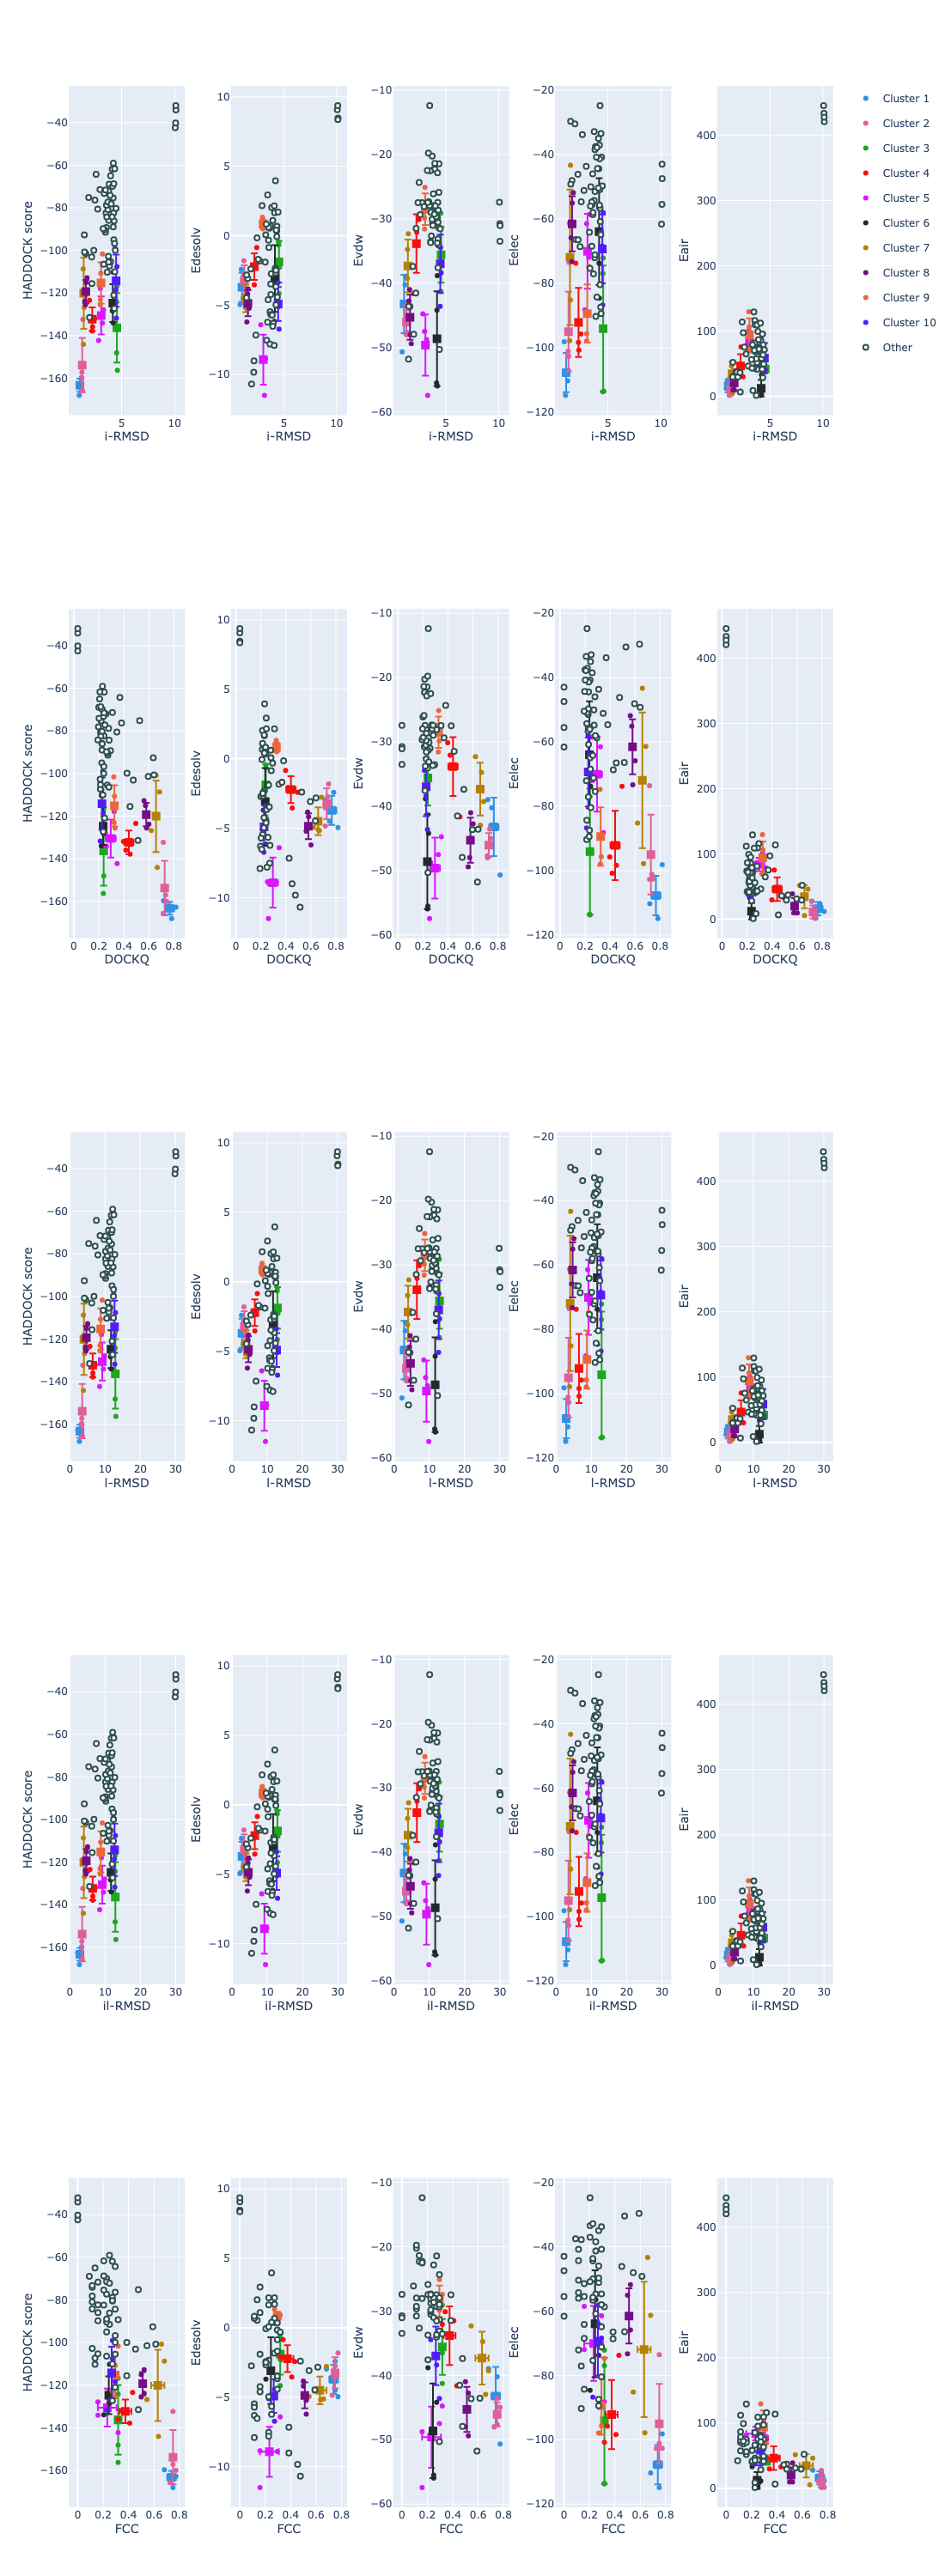

In [17]:
#@title View the various statistics plots
import json
import re
from IPython.display import display
import pandas as pd

# Specify the path to your HTML file
html_file_path = PROJECT_DIR  / "run_prot-glyc" / "analysis" / "12_caprieval_analysis/report.html"

# Read the HTML file
with open(html_file_path, 'r') as f:
    html_content = f.read()

# Use a regular expression to find the script tag with id="data1" and extract its content
match_plot = re.search(r'<script id="data1" type="application/json">\s*(.*?)\s*</script>', html_content, re.DOTALL)

if match_plot:
    json_data_str_plot = match_plot.group(1)
    # Load the JSON data
    plot_data = json.loads(json_data_str_plot)

    # Set width and height to None to make the plot responsive
    if 'layout' in plot_data:
        plot_data['layout']['width'] = None
        #plot_data['layout']['height'] = None

    # Display the plot using iplot
    iplot(plot_data)
else:
    print("Could not find the script tag with id='data1' in the HTML file.")

Finally, the report also shows plots of the cluster statistics (distributions of values per cluster ordered according to their HADDOCK rank).

To view those distribution plots execute the next cell.


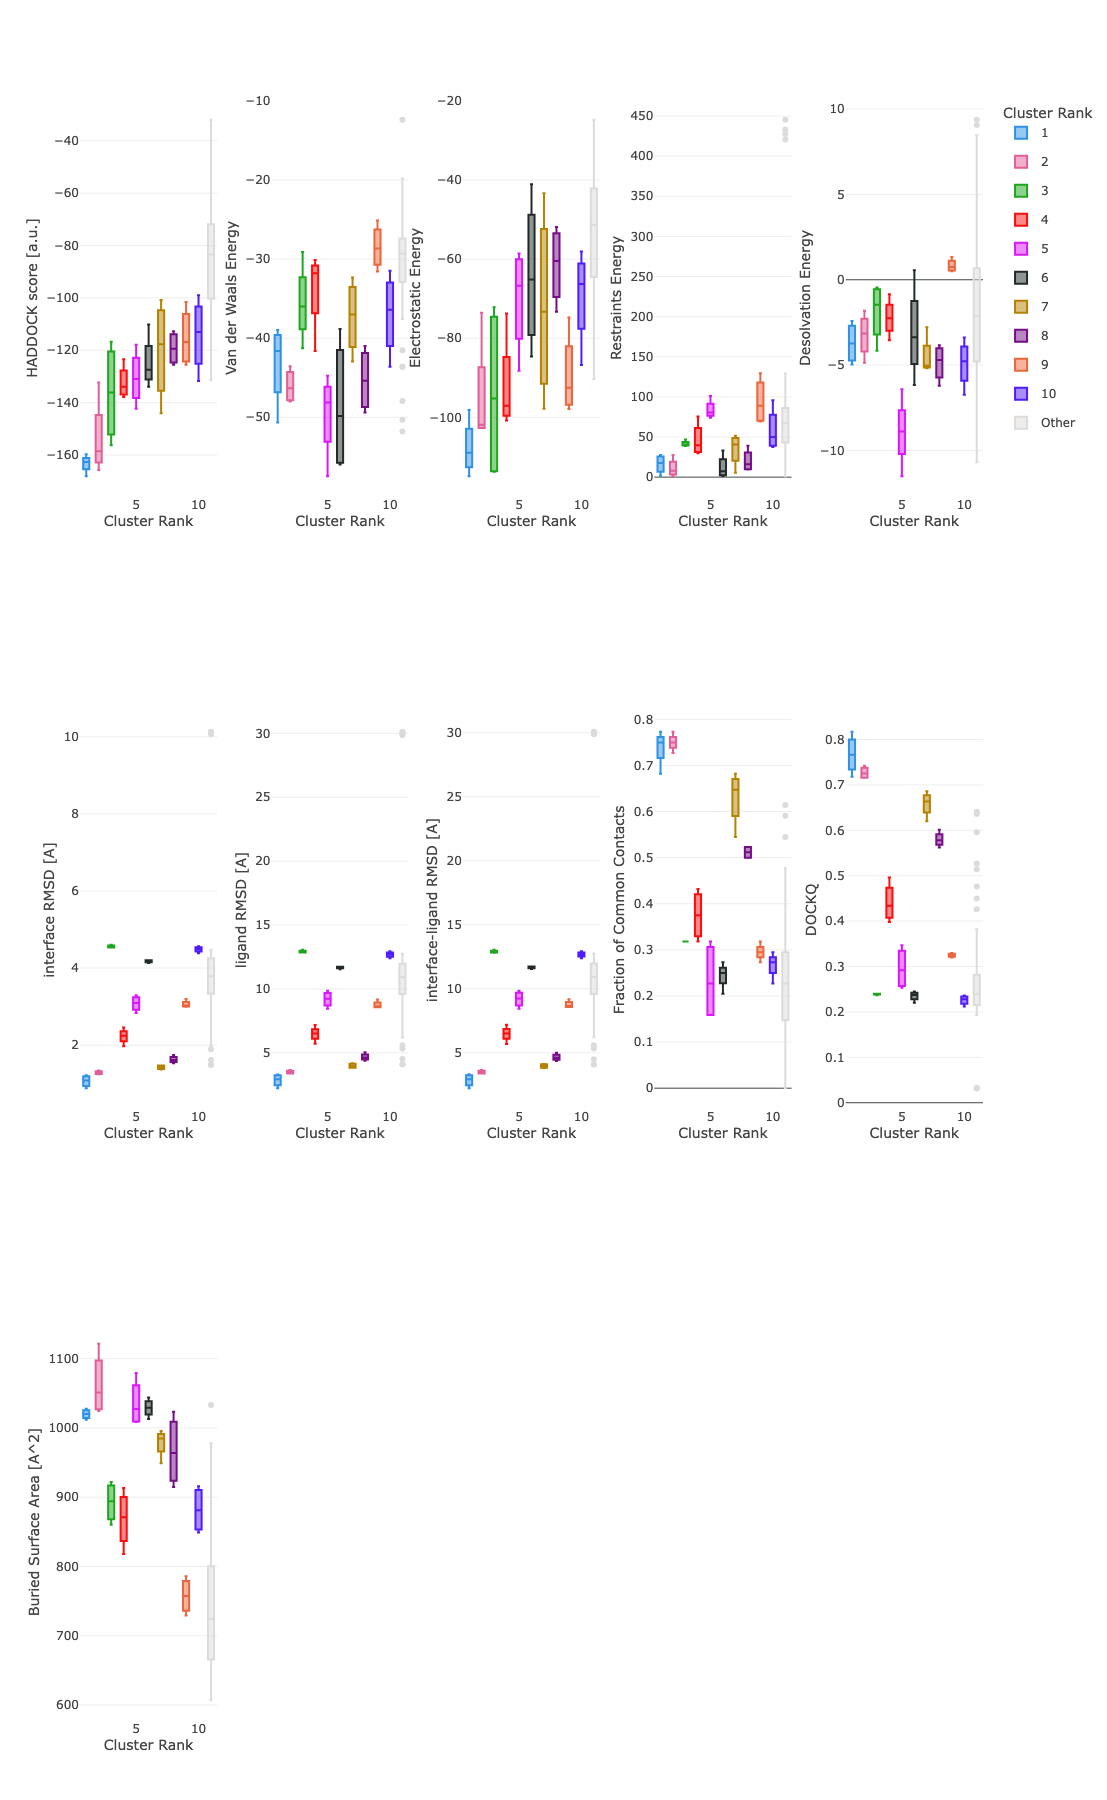

In [18]:

#@title View the various distribution plots
import json
import re
from plotly.offline import iplot

html_file_path = PROJECT_DIR / "run_prot-glyc" / "analysis" / "12_caprieval_analysis/report.html"

with open(html_file_path, 'r') as f:
    html_content = f.read()

match_plot = re.search(r'<script id="data2" type="application/json">\s*(.*?)\s*</script>', html_content, re.DOTALL)

if match_plot:
    json_data_str_plot = match_plot.group(1)
    plot_data = json.loads(json_data_str_plot)

    if 'layout' in plot_data:
        plot_data['layout']['width'] = None
        # Remove the template entirely — it contains deprecated trace types
        # (e.g. heatmapgl) that newer plotly versions no longer recognize
        plot_data['layout'].pop('template', None)

    iplot(plot_data, validate=False)
else:
    print("Could not find the script tag with id='data1' in the HTML file.")

# Contact Analysis



---
# Visualisation and comparison with the reference structure

To visualize the models from top cluster of your favorite run, start PyMOL and load the cluster representatives you want to view, e.g. this could be the top model from cluster1. These can be found in the `runs/run_prot-glyc/11_seletopclusts/` directory.

Let us unzip the files:

In [19]:
!gunzip -d runs/run_prot-glyc/11_seletopclusts/cluster_*.pdb.gz

runs/run_prot-glyc/11_seletopclusts/cluster_10_model_1.pdb already exists -- do you wish to overwrite (y or n)? ^C


You can load the models from the `run_prot-glyc/11_seletopclusts` directory in PyMOL. Will first check the top ranked cluster to see if this is good solution.

In [20]:
from pathlib import Path
from pymol import cmd
import gzip
import shutil
import py3Dmol

# --------------------------------------------------
# 1. Find the project directory
# --------------------------------------------------

BASE_DIR = Path.cwd()
PROJECT_NAME = "haddock3-protein-glycan"

if BASE_DIR.name == PROJECT_NAME:
    PROJECT_DIR = BASE_DIR
else:
    PROJECT_DIR = BASE_DIR / PROJECT_NAME

# --------------------------------------------------
# 2. Define folders and files
# --------------------------------------------------

MODEL_DIR = PROJECT_DIR / "runs" / "run_prot-glyc" / "11_seletopclusts"
PDB_DIR = PROJECT_DIR / "pdbs"

MODEL_GZ = MODEL_DIR / "cluster_1_model_1.pdb.gz"
MODEL_PDB = MODEL_DIR / "cluster_1_model_1.pdb"
REFERENCE_PDB = PDB_DIR / "1UU6_target.pdb"

print("Project directory:", PROJECT_DIR)
print("Model directory:", MODEL_DIR)

# --------------------------------------------------
# 3. Check that the folders exist
# --------------------------------------------------

if not PROJECT_DIR.exists():
    raise FileNotFoundError(f"Project folder not found: {PROJECT_DIR}")

if not MODEL_DIR.exists():
    raise FileNotFoundError(f"Model folder not found: {MODEL_DIR}")

if not REFERENCE_PDB.exists():
    raise FileNotFoundError(f"Reference structure not found: {REFERENCE_PDB}")

# --------------------------------------------------
# 4. Unzip the model if only the .pdb.gz file exists
# --------------------------------------------------

if not MODEL_PDB.exists():
    if not MODEL_GZ.exists():
        raise FileNotFoundError(
            f"Neither compressed nor uncompressed model was found:\n"
            f"{MODEL_GZ}\n"
            f"{MODEL_PDB}"
        )

    with gzip.open(MODEL_GZ, "rb") as compressed_file:
        with open(MODEL_PDB, "wb") as uncompressed_file:
            shutil.copyfileobj(compressed_file, uncompressed_file)

    print("Model was unzipped:", MODEL_PDB)
else:
    print("Uncompressed model already exists:", MODEL_PDB)

# --------------------------------------------------
# 5. Start a clean PyMOL session
# --------------------------------------------------

cmd.reinitialize()

# --------------------------------------------------
# 6. Load the model and reference structure
# --------------------------------------------------

cmd.load(str(MODEL_PDB), "cluster_1_model_1")
cmd.load(str(REFERENCE_PDB), "1UU6_target")

print("Loaded objects:", cmd.get_object_list())
print("Model chains:", cmd.get_chains("cluster_1_model_1"))
print("Reference chains:", cmd.get_chains("1UU6_target"))

# --------------------------------------------------
# 7. Align the protein parts
#    Chain A is assumed to be the protein
# --------------------------------------------------

alignment_result = cmd.align(
    "cluster_1_model_1 and chain A",
    "1UU6_target and chain A"
)

protein_alignment_rmsd = alignment_result[0]

print("Protein alignment RMSD:", protein_alignment_rmsd, "Å")

# --------------------------------------------------
# 8. Calculate the glycan RMSD
#    Chain B is assumed to be the glycan
# --------------------------------------------------

glycan_lrmsd = cmd.rms_cur(
    "1UU6_target and chain B",
    "cluster_1_model_1 and chain B"
)

print("Glycan L-RMSD:", glycan_lrmsd, "Å")

# --------------------------------------------------
# 9. Save the aligned coordinates
# --------------------------------------------------

ALIGNED_MODEL = PROJECT_DIR / "aligned_cluster_1_model_1.pdb"
ALIGNED_REFERENCE = PROJECT_DIR / "aligned_1UU6_target.pdb"

cmd.save(str(ALIGNED_MODEL), "cluster_1_model_1")
cmd.save(str(ALIGNED_REFERENCE), "1UU6_target")

print("Aligned model saved to:", ALIGNED_MODEL)
print("Reference saved to:", ALIGNED_REFERENCE)

# --------------------------------------------------
# 10. Create an interactive Jupyter visualization
# --------------------------------------------------

model_pdb_text = ALIGNED_MODEL.read_text()
reference_pdb_text = ALIGNED_REFERENCE.read_text()

view = py3Dmol.view(width=900, height=650)

# Add docked model
view.addModel(model_pdb_text, "pdb")

# Docked protein: cyan cartoon
view.setStyle(
    {"model": 0, "chain": "A"},
    {"cartoon": {"color": "cyan"}}
)

# Docked glycan: blue sticks and spheres
view.setStyle(
    {"model": 0, "chain": "B"},
    {
        "stick": {"color": "blue"}
    }
)

# Add reference structure
view.addModel(reference_pdb_text, "pdb")

# Reference protein: transparent yellow cartoon
view.setStyle(
    {"model": 1, "chain": "A"},
    {
        "cartoon": {
            "color": "yellow",
            "opacity": 0.65
        }
    }
)

# Reference glycan: orange sticks and spheres
view.setStyle(
    {"model": 1, "chain": "B"},
    {
        "stick": {"color": "orange"}
    }
)

view.setBackgroundColor("white")
view.zoomTo()
view.show()

Project directory: /Users/eceokur/Downloads/haddock3-protein-glycan
Model directory: /Users/eceokur/Downloads/haddock3-protein-glycan/runs/run_prot-glyc/11_seletopclusts
Uncompressed model already exists: /Users/eceokur/Downloads/haddock3-protein-glycan/runs/run_prot-glyc/11_seletopclusts/cluster_1_model_1.pdb
Loaded objects: ['cluster_1_model_1', '1UU6_target']
Model chains: ['A', 'B']
Reference chains: ['A', 'B']
Protein alignment RMSD: 0.22672908008098602 Å
Glycan L-RMSD: 12.675846099853516 Å
Aligned model saved to: /Users/eceokur/Downloads/haddock3-protein-glycan/aligned_cluster_1_model_1.pdb
Reference saved to: /Users/eceokur/Downloads/haddock3-protein-glycan/aligned_1UU6_target.pdb


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

__*How close are the top4 models of cluster_1 to the reference? Did HADDOCK do a good job at ranking the best in the top?*__

__*Did the glycan conformation improve thanks to the refinement in any of the selected models?*__

Now align chain B with the target and `cluster_1_model_1

In [21]:
from pathlib import Path
from pymol import cmd
import gzip
import shutil
import py3Dmol

# --------------------------------------------------
# 1. Find the project directory
# --------------------------------------------------

BASE_DIR = Path.cwd()
PROJECT_NAME = "haddock3-protein-glycan"

if BASE_DIR.name == PROJECT_NAME:
    PROJECT_DIR = BASE_DIR
else:
    PROJECT_DIR = BASE_DIR / PROJECT_NAME

# --------------------------------------------------
# 2. Define folders and files
# --------------------------------------------------

MODEL_DIR = PROJECT_DIR / "runs" / "run_prot-glyc" / "11_seletopclusts"
PDB_DIR = PROJECT_DIR / "pdbs"

MODEL_GZ = MODEL_DIR / "cluster_1_model_1.pdb.gz"
MODEL_PDB = MODEL_DIR / "cluster_1_model_1.pdb"
REFERENCE_PDB = PDB_DIR / "1UU6_target.pdb"

print("Project directory:", PROJECT_DIR)
print("Model directory:", MODEL_DIR)
print("Reference file:", REFERENCE_PDB)

# --------------------------------------------------
# 3. Check that required files/folders exist
# --------------------------------------------------

if not PROJECT_DIR.exists():
    raise FileNotFoundError(f"Project folder not found: {PROJECT_DIR}")

if not MODEL_DIR.exists():
    raise FileNotFoundError(f"Model folder not found: {MODEL_DIR}")

if not REFERENCE_PDB.exists():
    raise FileNotFoundError(f"Reference structure not found: {REFERENCE_PDB}")

# --------------------------------------------------
# 4. Unzip the model if needed
# --------------------------------------------------

if not MODEL_PDB.exists():
    if not MODEL_GZ.exists():
        raise FileNotFoundError(
            f"Neither compressed nor uncompressed model was found:\n"
            f"{MODEL_GZ}\n{MODEL_PDB}"
        )

    with gzip.open(MODEL_GZ, "rb") as compressed_file:
        with open(MODEL_PDB, "wb") as uncompressed_file:
            shutil.copyfileobj(compressed_file, uncompressed_file)

    print("Model unzipped:", MODEL_PDB)
else:
    print("Uncompressed model already exists:", MODEL_PDB)

# --------------------------------------------------
# 5. Start a clean PyMOL session
# --------------------------------------------------

cmd.reinitialize()

# --------------------------------------------------
# 6. Load structures
# --------------------------------------------------

cmd.load(str(MODEL_PDB), "cluster_1_model_1")
cmd.load(str(REFERENCE_PDB), "1UU6_target")

print("Loaded objects:", cmd.get_object_list())
print("Model chains:", cmd.get_chains("cluster_1_model_1"))
print("Reference chains:", cmd.get_chains("1UU6_target"))

# --------------------------------------------------
# 7. Align chain B to chain B with cycles=0
#    This is the exact command you asked for
# --------------------------------------------------

alignment_result = cmd.align(
    "cluster_1_model_1 and chain B",
    "1UU6_target and chain B",
    cycles=0
)

print("Alignment RMSD (chain B to chain B):", alignment_result[0], "Å")
print("Aligned atoms:", alignment_result[1])

# --------------------------------------------------
# 8. Calculate RMSD again for chain B
#    after the alignment
# --------------------------------------------------

chainB_rmsd = cmd.rms_cur(
    "1UU6_target and chain B",
    "cluster_1_model_1 and chain B"
)

print("Chain B RMSD after alignment:", chainB_rmsd, "Å")

# --------------------------------------------------
# 9. Save aligned structures
# --------------------------------------------------

ALIGNED_MODEL = PROJECT_DIR / "aligned_cluster_1_model_1.pdb"
ALIGNED_REFERENCE = PROJECT_DIR / "aligned_1UU6_target.pdb"

cmd.save(str(ALIGNED_MODEL), "cluster_1_model_1")
cmd.save(str(ALIGNED_REFERENCE), "1UU6_target")

print("Aligned model saved to:", ALIGNED_MODEL)
print("Aligned reference saved to:", ALIGNED_REFERENCE)

# --------------------------------------------------
# 10. Create interactive visualization in Jupyter
# --------------------------------------------------

model_pdb_text = ALIGNED_MODEL.read_text()
reference_pdb_text = ALIGNED_REFERENCE.read_text()

view = py3Dmol.view(width=900, height=650)

# Add aligned model
view.addModel(model_pdb_text, "pdb")

# Model chain A
view.setStyle(
    {"model": 0, "chain": "A"},
    {"cartoon": {"color": "cyan"}}
)

# Model chain B
view.setStyle(
    {"model": 0, "chain": "B"},
    {
        "stick": {"color": "blue"}
    }
)

# Add reference
view.addModel(reference_pdb_text, "pdb")

# Reference chain A
view.setStyle(
    {"model": 1, "chain": "A"},
    {"cartoon": {"color": "yellow", "opacity": 1}}
)

# Reference chain B
view.setStyle(
    {"model": 1, "chain": "B"},
    {
        "stick": {"color": "orange"}
    }
)

view.setBackgroundColor("white")
view.zoomTo()
view.show()

Project directory: /Users/eceokur/Downloads/haddock3-protein-glycan
Model directory: /Users/eceokur/Downloads/haddock3-protein-glycan/runs/run_prot-glyc/11_seletopclusts
Reference file: /Users/eceokur/Downloads/haddock3-protein-glycan/pdbs/1UU6_target.pdb
Uncompressed model already exists: /Users/eceokur/Downloads/haddock3-protein-glycan/runs/run_prot-glyc/11_seletopclusts/cluster_1_model_1.pdb
Loaded objects: ['cluster_1_model_1', '1UU6_target']
Model chains: ['A', 'B']
Reference chains: ['A', 'B']
Alignment RMSD (chain B to chain B): 2.478548049926758 Å
Aligned atoms: 45
Chain B RMSD after alignment: 2.4785478115081787 Å
Aligned model saved to: /Users/eceokur/Downloads/haddock3-protein-glycan/aligned_cluster_1_model_1.pdb
Aligned reference saved to: /Users/eceokur/Downloads/haddock3-protein-glycan/aligned_1UU6_target.pdb


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Now repeat this analysis but with the cluster with the lowest ilRMSD values.(ranked #2)

Let’s now check if the active residues which we have defined (the protein binding site) are actually part of the interface.

__*How close are the top4 models of this cluster to the reference?*__

__*What was the rank of this cluster?*__

In [22]:
from pathlib import Path
from haddock.libs.libnotebooks import align_full

# Project paths
BASE_DIR = Path.cwd()
PROJECT_DIR = (
    BASE_DIR
    if BASE_DIR.name == "haddock3-protein-glycan"
    else BASE_DIR / "haddock3-protein-glycan"
)

MODEL_DIR = PROJECT_DIR / "run_prot-glyc" / "11_seletopclusts"
PDB_DIR = PROJECT_DIR / "pdbs"

model_path = MODEL_DIR / "cluster_2_model_1.pdb"
reference_path = PDB_DIR / "1UU6_target.pdb"

# Align the proteins using chain A
result = align_full(
    str(model_path),
    str(reference_path),
    chains=["A"]
)

view = result[0] if isinstance(result, tuple) else result

# Remove all default representations
view.setStyle({})
view.setBackgroundColor("#dfe6e9")

# Docked protein: green
view.addStyle(
    {"model": 0, "chain": "A"},
    {"cartoon": {"color": "green"}}
)

# Reference protein: yellow
view.addStyle(
    {"model": 1, "chain": "A"},
    {"cartoon": {"color": "yellow"}}
)

# Docked glycan: cyan carbons, red oxygens, white hydrogens
view.addStyle(
    {"model": 0, "chain": "B"},
    {
        "stick": {
            "colorscheme": "cyanCarbon",
            "radius": 0.18
        }
    }
)

# Reference glycan: yellow carbons, red oxygens, white hydrogens
view.addStyle(
    {"model": 1, "chain": "B"},
    {
        "stick": {
            "colorscheme": "yellowCarbon",
            "radius": 0.18
        }
    }
)

# Focus on both glycans
view.zoomTo({"chain": "B"})
view.show()

Atoms for alignment - Model 1: {'A': 223}, Total: 223
Atoms for alignment - Model 2: {'A': 223}, Total: 223
Model 1: chain A in red
Model 2: chain A in blue
Using 223 atom pairs for alignment
Whole molecule alignment RMSD: 0.311 Å
Chain A RMSD: 0.311 Å


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

__*Are the residues of the binding_site at the interface with the glycan?*__

---
# Conclusions

In this tutorial we have demonstrated the use of HADDOCK3 to predict the structure of a protein-glycan complex using information about the protein binding site. We have shown how to prepare the PDB files for docking, define the restraints, and set up the docking protocol. We have also discussed the analysis of the docking results and the comparison with the reference structure.

We hope you have enjoyed this tutorial and that you have learned something new. If you have any questions or feedback, please do not hesitate to contact us on the [HADDOCK forum](https://ask.bioexcel.eu/c/haddock/6).

---
# BONUS1: Using an ensemble of glycan conformations
## Creating an ensemble of glycan conformations

We have just modelled a single conformation of the glycan. However, glycans are highly flexible molecules that can adopt multiple conformations. Indeed, the modelled glycan is quite different from the conformation adopted in the reference structure. To account for this flexibility, we can generate an ensemble of glycan structures that will be docked to the protein.

To do this, we will use the short Molecular Dynamics refinement protocol available in HADDOCK3. This protocol will generate an ensemble of glycan conformations by running short MD simulations on the glycan structure. The hope here is to observe a glycan structure that is significantly closer to the structure observed in the complex (bound conformation). You are encouraged to try more extensive and optimized MD software for this task, such as [GROMACS](https://www.gromacs.org/) and [OPENMM](https://openmm.org/), but for the sake of this tutorial, we will use HADDOCK3.

We will use the following protocol, available as `glycan-mdref.cfg` in the `haddock3` directory of the archive you downloaded:

```toml
# ====================================================================
# MD Refinment of the glycan conformation
# ====================================================================
run_dir = "run-glycan-mdref"

# execution mode
mode = "local"
ncores = 10

# starting glycan conformation
molecules =  [
    "../pdbs/1UU6_l_u.pdb",
    ]

# ====================================================================
# Parameters for each stage are defined below, prefer full paths
# ====================================================================
[topoaa]

[mdref]
tolerance = 5
nfle1 = 1
fle_sta_1_1 = 1
fle_end_1_1 = 4
sampling_factor = 20
nemsteps = 200
waterheatsteps = 100
watersteps = 20000
watercoolsteps = 8000

[rmsdmatrix]

[clustrmsd]
criterion = 'distance'
linkage = 'average'
min_population = 1
clust_cutoff = 0.6

[seletopclusts]
top_models = 1
````


This protocol will run a short MD simulation on the glycan structure, generate an ensemble of conformations, cluster them based on their RMSD using a 0.6Å cutoff, and select the cluster center from each cluster.

__Note__ how the glycan is here defined as fully flexible (nfle1 = 1). The number of steps of the different mdref parameters has also been increased with respect to the default values to ensure a better sampling of the conformational space. The sampling factor has been set to 16 to generate 16 conformations.

__*If you have sufficient computing power try to increase the sampling factor to 400.*__

To run the protocol above, go into the `haddock3` directory and execute the following command:

In [25]:
!haddock3 "{PROJECT_DIR / "haddock3" /"glycan-mdref.cfg"}" 

[2026-07-27 15:41:18,567 cli INFO] 
##############################################
#                                            #
#                 HADDOCK3                   #
#                                            #
##############################################

!! Some of the HADDOCK3 components use CNS (Crystallographic and NMR System) which is free of use for non-profit applications. !!
!! For commercial use it is your own responsibility to have a proper license. !!
!! For details refer to the DISCLAIMER file in the HADDOCK3 repository. !!

Starting HADDOCK3 v2026.7.0 on 2026-07-27 15:41:00

Python 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:59:26) [Clang 19.1.7 ]

[2026-07-27 15:41:19,500 libutil ERROR] The parameter block 'fle1_*_1_*' is not a valid expandable parameter.
Traceback (most recent call last):
  File "/opt/anaconda3/envs/haddock3-env/lib/python3.11/site-packages/haddock/libs/libutil.py", line 383, in log_error_and_exit
    yield
  File "/opt/ana

/Users/eceokur/Downloads


This will generate a new directory `run-glycan-mdref` with the results of the MD refinement. In particular, we are interested in the content of the 4_selectopclusts directory, which contains the selected models from each cluster. The clusters in that directory are numbered based on their rank, i.e. `cluster_1`refers to the top-ranked cluster. Let us unzip these files:



In [20]:
!gzip -d run-glycan-mdref/4_seletopclusts/cluster*pdb*gz



gzip: can't stat: run-glycan-mdref/4_seletopclusts/cluster*pdb*gz (run-glycan-mdref/4_seletopclusts/cluster*pdb*gz.gz): No such file or directory


and create an ensemble of conformations:



In [21]:
!pdb_mkensemble run-glycan-mdref/4_seletopclusts/cluster*pdb | pdb_tidy > 1UU6_l_u_ens.pdb

ERROR!! File not found or not readable: 'run-glycan-mdref/4_seletopclusts/cluster*pdb'

Merges several PDB files into one multi-model (ensemble) file.

Strips all HEADER information and adds REMARK statements with the provenance
of each conformer.

Usage:
    python pdb_mkensemble.py <pdb file> <pdb file>

Example:
    python pdb_mkensemble.py 1ABC.pdb 1XYZ.pdb

This program is part of the `pdb-tools` suite of utilities and should not be
distributed isolatedly. The `pdb-tools` were created to quickly manipulate PDB
files using the terminal, and can be used sequentially, with one tool streaming
data to another. They are based on old FORTRAN77 code that was taking too much
effort to maintain and compile. RIP.


Now we can compare the ensemble of glycan conformations with the reference structure. To do this, we will superimpose the two structures and calculate the RMSD.

In [ ]:
PYMOL

---
# Docking from an ensemble of glycan conformations

[In a previous BONUS section](https://www.bonvinlab.org/education/HADDOCK3/HADDOCK3-protein-glycan/#bonus-section-creating-an-ensemble-of-glycan-conformations) we described how to generate an ensemble of glycan conformations using a short MD refinement protocol. We can now use this ensemble to dock the protein to multiple glycan conformations.

To do this, we will use the `protein-glycan-ens.cfg`, available in the `haddock3` directory of the archive you downloaded.
Besides the presence of the glycan ensemble (`1UU6_l_u_ens`) in place of the single structure (`1UU6_l_u`, the only difference between this protocol and the [previous](https://www.bonvinlab.org/education/HADDOCK3/HADDOCK3-protein-glycan/#setting-up-the-docking-with-haddock3) one is the `sampling` parameter at the rigidbody docking level: as multiple conformations are being docked, in order to sample each starting conformation a sufficient amount of time we increase the number of models generated:

```toml
...
run_dir = "run_prot-gly_ensemble"

# list, insert full path
molecules = [
    "../pdbs/1OLR_clean.pdb",
    "../pdbs/1UU6_l_u_ens.pdb",
]

[topoaa]

[rigidbody]
ambig_fname = "../restraints/ambig.tbl"
w_vdw = 1
sampling = 4000

[caprieval]
reference_fname = "../pdbs/1UU6_target.pdb"
...
````



__*Given the previously calculated RMSDs between the ensemble elements and the bound glycan structure, is the ensemble docking protocol likely to perform better than the standard, single input workflow?*__

Such information would not be available in a realistic modelling scenario, as the bound structure (1UU6 here) would be unknown.

---
# BONUS2: Modifying the scoring weights at the flexible refinement stage

In the HADDOCK3 configuration file we have used in this tutorial, the scoring weights for the flexible refinement stage are set to the default values. This can be found [here](https://www.bonvinlab.org/software/haddock2.4/scoring/).

Glycans are quite hydrophobic molecules and, in a protein-glycan complex, the van der Waals energy is typically playing a more important role than the electrostatic interactions. We can therefore try to decrease the weight of the electrostatic energy term at the flexible refinement stage.

To do this, we need to modify the configuration file. The relevant section is the `flexref` module:

```toml
[flexref]
ambig_fname = "../restraints/ambig.tbl"
tolerance = 5
w_elec = 0.4
```

Setting `w_elec` to 0.4 (in place of 1.0) will downscale the electrostatic weight by a factor of 2.5.

You can now try to run the docking again with this new configuration file. You can either do this by running the modified configuration file (`protein-glycan-elec.cfg`, always from the `haddock3` directory):

/Users/eceokur/Downloads/haddock3-protein-glycan
